# Head Capacity Paradox: LP vs MLP Probe vs Attentive Probe

Reads a `results/mae_har/*.json` file and compares accuracy across probe types (Linear Probe, MLP Probe, Attentive Probe light/heavy) on `test_id` vs the three OOD splits (`test_cross_device`, `test_cross_env`, `test_cross_user`).

**Key question this answers:** does more head capacity (LP -> MLP -> Attentive) help or hurt OOD generalization, even though it consistently helps in-distribution accuracy?

Attentive probe columns (`attn_light_acc` / `attn_heavy_acc`) only exist in result JSONs produced by a run with `--run_attentive_probe` enabled. If they're missing, this notebook automatically skips them and compares whatever protocols ARE present (at minimum KNN/LP/MLP, which every run has).

In [8]:
import json
import matplotlib.pyplot as plt
import numpy as np

## Config -- edit these two lines for the checkpoint/layer you want to visualize

In [9]:
RESULT_JSON = "/home/zhuzih19/csi-project/csi-fall-detection/results/mae_har/mae_har_ep150_mask0.75_strategyrandom_ph29pw25_seed42_enc12_dim128_bs128.json"
LAYER = 12  # encoder layer to visualize

In [10]:
with open(RESULT_JSON) as f:
    result = json.load(f)

# Auto-select the LAST (highest-epoch) eval checkpoint stored in this JSON --
# every ablation table in this project reads final-epoch numbers, so this matches
# that convention instead of requiring you to hardcode an epoch number.
final_ckpt = sorted(result['evals'].keys(), key=lambda k: int(k.split('_')[1]))[-1]
layer_evals = result['evals'][final_ckpt][f'layer_{LAYER}']

print(f"Config: {result['exp']}")
print(f"Using checkpoint: {final_ckpt}, layer: {LAYER}")

Config: mae_har_ep150_mask0.75_strategyrandom_ph29pw25_seed42_enc12_dim128_bs128
Using checkpoint: epoch_150, layer: 12


In [11]:
splits = ['test_id', 'test_cross_device', 'test_cross_env', 'test_cross_user']
split_labels = ['ID', 'Cross-Device', 'Cross-Env', 'Cross-User']

# Maps a human-readable protocol name -> the JSON key it's stored under.
# KNN is intentionally excluded here -- it's a non-parametric baseline (no head at
# all), not a point on the "head capacity" spectrum this notebook is comparing.
protocol_keys = {
    'LP': 'lp_acc',
    'MLP probe': 'mlp_acc',
    'Attentive (light)': 'attn_light_acc',
    'Attentive (heavy)': 'attn_heavy_acc',
}

available_protocols = {}
for name, key in protocol_keys.items():
    values = [layer_evals[s].get(key) for s in splits]
    if all(v is not None for v in values):
        available_protocols[name] = values
    else:
        print(f"[skip] '{name}' ({key}) not found in this JSON -- "
              f"likely this run didn't use --run_attentive_probe. Skipping.")

if len(available_protocols) < 2:
    raise ValueError(
        "Need at least 2 protocols with data to make a meaningful comparison. "
        "Check RESULT_JSON/LAYER, or rerun with --run_attentive_probe if you want "
        "attentive probe columns."
    )

print(f"\nComparing: {list(available_protocols.keys())}")


Comparing: ['LP', 'MLP probe', 'Attentive (light)', 'Attentive (heavy)']


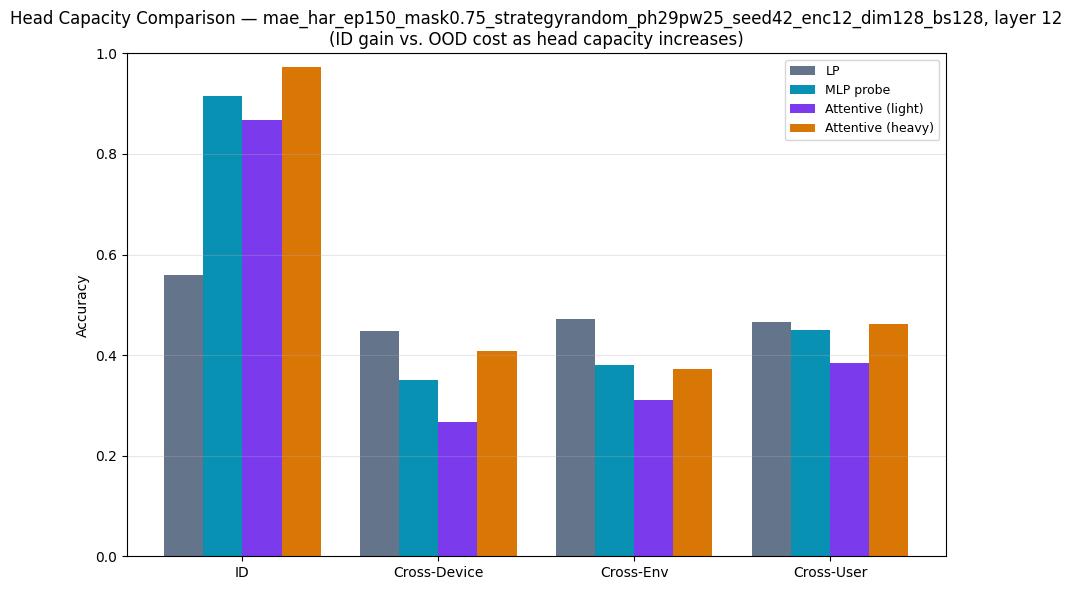

In [12]:
colors = {
    'LP': '#64748B',
    'MLP probe': '#0891B2',
    'Attentive (light)': '#7C3AED',
    'Attentive (heavy)': '#D97706',
}

fig, ax = plt.subplots(figsize=(9, 6))
n_protocols = len(available_protocols)
width = 0.8 / n_protocols
x = np.arange(len(splits))

for i, (name, values) in enumerate(available_protocols.items()):
    offset = (i - (n_protocols - 1) / 2) * width
    ax.bar(x + offset, values, width=width, label=name, color=colors.get(name, None))

ax.set_xticks(x)
ax.set_xticklabels(split_labels)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.0)
ax.set_title(f'Head Capacity Comparison \u2014 {result["exp"]}, layer {LAYER}\n'
             f'(ID gain vs. OOD cost as head capacity increases)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')
fig.tight_layout()
plt.show()

## ID-OOD generalization gap

For each protocol: `gap = ID_accuracy - mean(OOD_accuracy)`. A **smaller** gap means the protocol's in-distribution accuracy isn't coming at the expense of out-of-distribution generalization -- i.e. it generalizes better, even if its raw ID number is lower.

In [13]:
print(f"{'Protocol':<20}{'ID':>8}{'OOD avg':>10}{'ID-OOD gap':>12}")
gap_rows = []
for name, values in available_protocols.items():
    id_acc = values[0]
    ood_avg = np.mean(values[1:])
    gap = id_acc - ood_avg
    gap_rows.append((name, id_acc, ood_avg, gap))
    print(f"{name:<20}{id_acc:>8.3f}{ood_avg:>10.3f}{gap:>12.3f}")

print("\nRanked by generalization (smallest gap = most generalizable):")
for name, id_acc, ood_avg, gap in sorted(gap_rows, key=lambda r: r[3]):
    print(f"  {gap:.3f}  {name}")

Protocol                  ID   OOD avg  ID-OOD gap
LP                     0.558     0.462       0.097
MLP probe              0.915     0.394       0.522
Attentive (light)      0.867     0.320       0.547
Attentive (heavy)      0.974     0.414       0.560

Ranked by generalization (smallest gap = most generalizable):
  0.097  LP
  0.522  MLP probe
  0.547  Attentive (light)
  0.560  Attentive (heavy)
